# Step 1: Data Understanding

This notebook prepares the shared dataset split and preprocessing flow for all later experiments.

Roadmap coverage:
- load the Breast Cancer Wisconsin dataset
- inspect shape, classes, missing values and descriptive statistics
- visualize class balance and target-related correlations
- apply stratified train/validation/test split
- standardize features using only the training split
- save summary tables and figures for later notebooks and the final report

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = str(PROJECT_ROOT / "src")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

from data_utils import (
    class_distribution,
    create_stratified_splits,
    load_breast_cancer_dataframe,
    scaled_feature_check,
    split_summary,
    summarize_dataframe,
    top_target_correlations,
)
from project_config import DATASET_NAME, RANDOM_SEED, TEST_SIZE, VALIDATION_SIZE, set_global_seed

set_global_seed()
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES_STEP1 = OUTPUT_FIGURES / "step1"
FIGURES_STEP2 = OUTPUT_FIGURES / "step2"
FIGURES_STEP1.mkdir(parents=True, exist_ok=True)
FIGURES_STEP2.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATASET_NAME}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Configured split ratios -> test: {TEST_SIZE:.2f}, validation: {VALIDATION_SIZE:.2f}")


Dataset: Breast Cancer Dataset
Random seed: 42
Configured split ratios -> test: 0.20, validation: 0.20


## Load Dataset and Build Core Tables

In [2]:
X, y, target_names = load_breast_cancer_dataframe()

dataset_summary = summarize_dataframe(X, y)
class_summary = class_distribution(y, target_names)
correlation_summary = top_target_correlations(X, y, n=10)
missing_summary = X.isna().sum().sort_values(ascending=False).rename("missing_values").reset_index()
missing_summary.columns = ["feature", "missing_values"]
descriptive_stats = X.describe().T[["mean", "std", "min", "max"]].sort_index()

dataset_summary.to_csv(OUTPUT_TABLES / "dataset_summary.csv", index=False)
class_summary.to_csv(OUTPUT_TABLES / "class_distribution.csv", index=False)
correlation_summary.to_csv(OUTPUT_TABLES / "top_target_correlations.csv", index=False)
missing_summary.to_csv(OUTPUT_TABLES / "missing_values.csv", index=False)
descriptive_stats.to_csv(OUTPUT_TABLES / "descriptive_statistics.csv")

display(dataset_summary)
display(class_summary)
display(correlation_summary)


,num_samples,num_features,positive_class_ratio,missing_values,duplicate_rows
0,569,30,0.627417,0,0


,class_id,class_name,count,ratio
0,0,malignant,212,0.372583
1,1,benign,357,0.627417


,feature,correlation_with_target,absolute_correlation
0,worst concave points,-0.793566,0.793566
1,worst perimeter,-0.782914,0.782914
2,mean concave points,-0.776614,0.776614
3,worst radius,-0.776454,0.776454
4,mean perimeter,-0.742636,0.742636
5,worst area,-0.733825,0.733825
6,mean radius,-0.730029,0.730029
7,mean area,-0.708984,0.708984
8,mean concavity,-0.696360,0.696360
9,worst concavity,-0.659610,0.659610


In [3]:
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Total missing values: {int(X.isna().sum().sum())}")
print(f"Duplicate feature rows: {int(X.duplicated().sum())}")

display(missing_summary.head(10))
display(descriptive_stats.head(10))


Feature matrix shape: (569, 30)
Target vector shape: (569,)
Total missing values: 0
Duplicate feature rows: 0


,feature,missing_values
0,mean radius,0
1,mean texture,0
2,worst symmetry,0
3,worst concave points,0
4,worst concavity,0
5,worst compactness,0
6,worst smoothness,0
7,worst area,0
8,worst perimeter,0
9,worst texture,0


,mean,std,min,max
area error,40.337079,45.491006,6.802000,542.20000
compactness error,0.025478,0.017908,0.002252,0.13540
concave points error,0.011796,0.006170,0.000000,0.05279
concavity error,0.031894,0.030186,0.000000,0.39600
fractal dimension error,0.003795,0.002646,0.000895,0.02984
mean area,654.889104,351.914129,143.500000,2501.00000
mean compactness,0.104341,0.052813,0.019380,0.34540
mean concave points,0.048919,0.038803,0.000000,0.20120
mean concavity,0.088799,0.079720,0.000000,0.42680
mean fractal dimension,0.062798,0.007060,0.049960,0.09744


## Visual Inspection

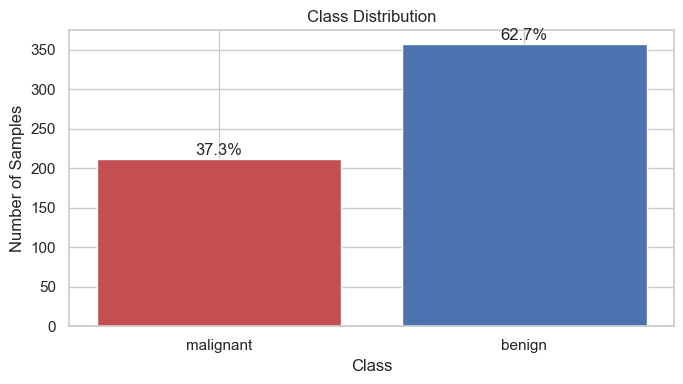

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(class_summary["class_name"], class_summary["count"], color=["#c44e52", "#4c72b0"])
ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Samples")
for idx, row in class_summary.iterrows():
    ax.text(idx, row["count"] + 5, f"{row['ratio']:.1%}", ha="center")
fig.tight_layout()
fig.savefig(FIGURES_STEP1 / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


### Feature Distribution Analysis
To justify the use of StandardScaler, we examine the distribution of features with the highest correlation with the target variable. Significant differences in scales (e.g., between 'area' and 'concave points') can cause gradient updates in models like Logistic Regression and MLP to be dominated by features with larger magnitudes.

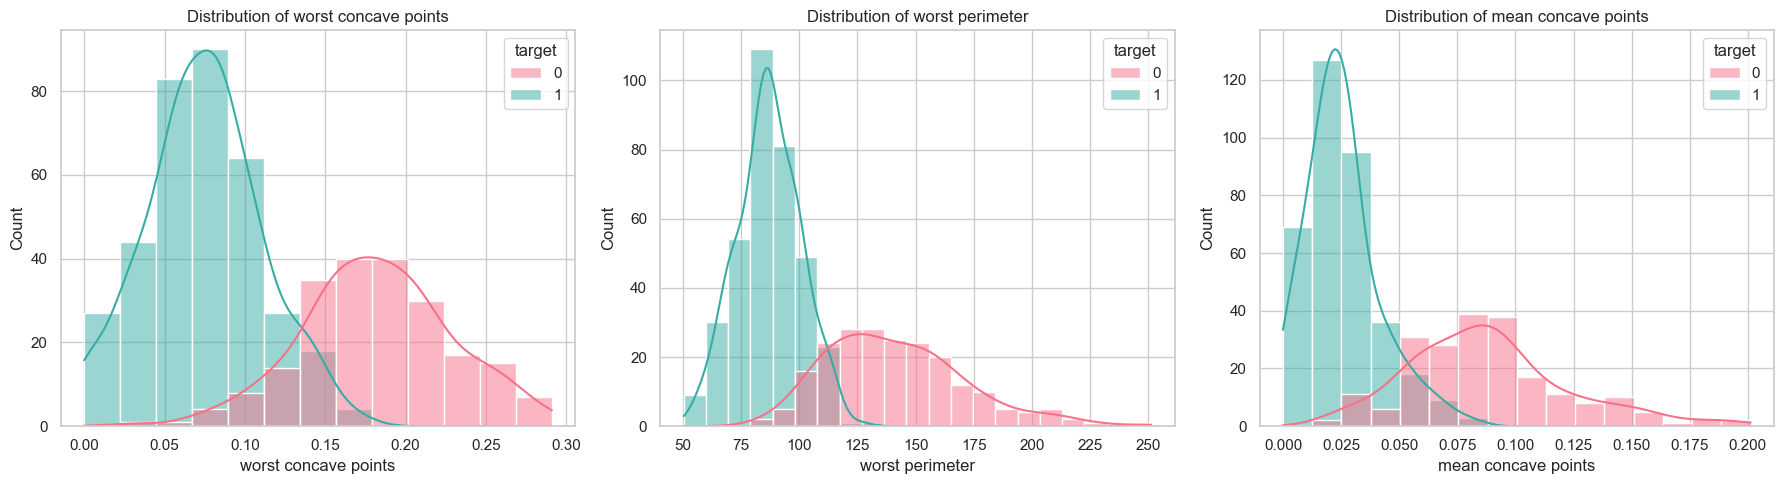

In [5]:
top_3_features = ["worst concave points", "worst perimeter", "mean concave points"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(top_3_features):
    sns.histplot(data=X, x=feat, hue=y, kde=True, ax=axes[i], palette="husl")
    axes[i].set_title(f"Distribution of {feat}")

fig.tight_layout()
fig.savefig(FIGURES_STEP1 / "top_features_distribution.png", dpi=200)
plt.show()


### Target Correlation and Multicollinearity Analysis
To prepare for future modeling phases, we analyze the correlation of the top features with the target variable, as well as their correlations with each other.

**Methodological Justification:**
1. **Predictive Power:** Identifying features highly correlated with the target (e.g., `worst concave points`) confirms the dataset's viability for our predictive goals.
2. **Multicollinearity Prevention:** If features are excessively correlated with each other (e.g., `mean radius` and `mean perimeter`), the resulting multicollinearity can cause models (especially deep MLPs) to over-rely on specific weights, leading to overfitting. By identifying these relationships early, we mathematically justify the need for **L2 Regularization (Weight Decay)** to penalize such over-reliance and improve generalization.

### Target Correlation and Multicollinearity Analysis
To prepare for future modeling phases, we analyze the correlation of the top features with the target variable, as well as their correlations with each other.

**Methodological Justification:**
1. **Predictive Power:** Identifying features highly correlated with the target (e.g., ) confirms the dataset's viability for our predictive goals.
2. **Multicollinearity Prevention:** If features are excessively correlated with each other (e.g.,  and ), the resulting multicollinearity can cause models (especially deep MLPs) to over-rely on specific weights, leading to overfitting. By identifying these relationships early, we mathematically justify the need for **L2 Regularization (Weight Decay)** to penalize such over-reliance and improve generalization.

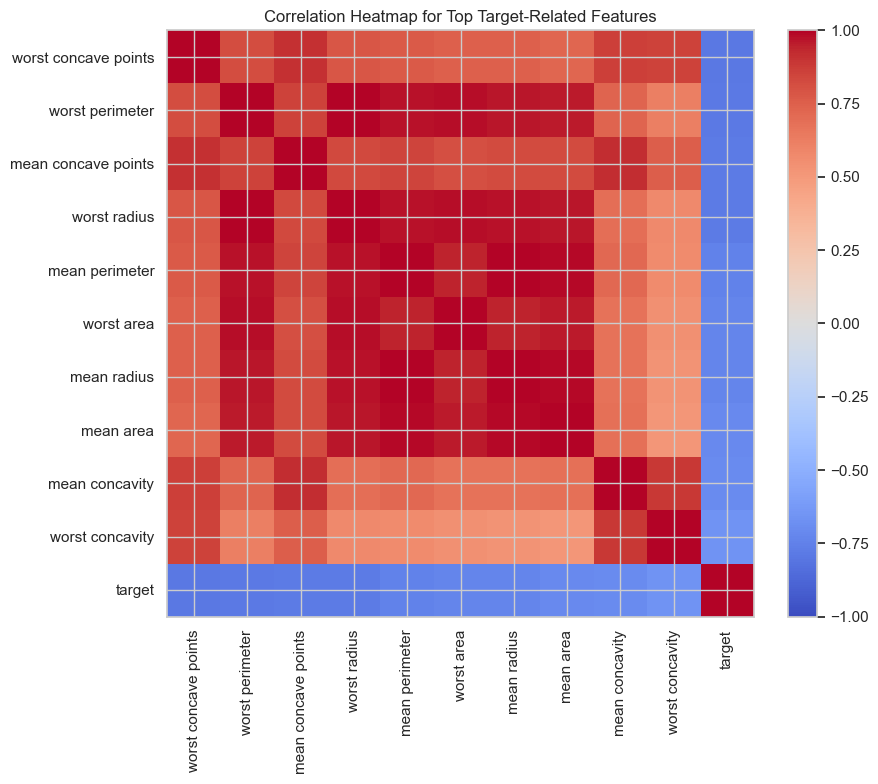

In [6]:
top_features = correlation_summary["feature"].tolist()
corr_frame = X[top_features].assign(target=y)

corr_matrix = corr_frame.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Correlation Heatmap for Top Target-Related Features")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURES_STEP1 / "top_feature_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


### Methodological Justification
1. **Stratified Split**: Given the ~63/37 class distribution, stratification ensures that each split (train, validation, test) remains representative of the total population. This is critical for reliably calculating metrics like F1-score which depend on the minority class frequency.
2. **Standardization**: `StandardScaler` (Z-score normalization) is applied here. It centers the distribution around zero with unit variance. For gradient-based optimizers (SGD, Adam), this prevents the 'vanishing/exploding gradient' issues caused by disparate feature scales and speeds up convergence.

## Preprocessing Pipeline

In [7]:
split = create_stratified_splits()
split_table = split_summary(split)
scaling_check = scaled_feature_check(split)

split_table.to_csv(OUTPUT_TABLES / "split_summary.csv", index=False)
scaling_check.to_csv(OUTPUT_TABLES / "scaling_check.csv", index=False)

display(split_table)
display(scaling_check)

print("Train shape:", split.X_train_raw.shape)
print("Validation shape:", split.X_val_raw.shape)
print("Test shape:", split.X_test_raw.shape)


,split,samples,positive_ratio
0,train,341,0.627566
1,validation,114,0.622807
2,test,114,0.631579


,feature,train_mean_after_scaling,train_std_after_scaling
0,mean radius,6.511572e-17,1.0
1,mean texture,1.041852e-17,1.0
2,mean perimeter,1.146037e-16,1.0
3,mean area,1.745101e-16,1.0
4,mean smoothness,1.446871e-15,1.0


Train shape: (341, 30)
Validation shape: (114, 30)
Test shape: (114, 30)


In [8]:
feature_preview = pd.concat(
    [
        split.X_train_raw.head(3).reset_index(drop=True),
        split.X_train_scaled.head(3).reset_index(drop=True).add_prefix("scaled_"),
    ],
    axis=1,
)
display(feature_preview.iloc[:, :8])


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points
0,9.676,13.14,64.12,272.5,0.12550,0.2204,0.11880,0.07038
1,14.250,21.72,93.63,633.0,0.09823,0.1098,0.13190,0.05598
2,12.540,16.32,81.25,476.3,0.11580,0.1085,0.05928,0.03279


## Technical Notes

- The dataset contains 569 samples and 30 numeric features, which makes it appropriate for both a strong logistic regression baseline and controlled MLP experiments.
- No missing values are present, so the preprocessing pipeline stays focused on split discipline and feature scaling instead of imputation.
- Stratified splitting keeps malignant/benign balance consistent across train, validation and test sets; this is required for fair model comparison.
- Standardization is fit only on the training data and then applied to validation/test sets, preventing information leakage.
- The tables saved under `outputs/tables/` and figures saved under `outputs/figures/step1/` will be reused in later notebooks and the final report.